<a href="https://colab.research.google.com/github/Ayeshafarheen11/NLP_Ass/blob/main/2403A52243_NLP_A10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 34.1 MB/s eta 0:00:00


In [2]:
from gensim.models import KeyedVectors
import gensim.downloader as api
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE


In [3]:
model_word2vec = api.load("word2vec-google-news-300")
model_glove = api.load("glove-wiki-gigaword-100")

[==================================================] 100.0% 1662.8/1662.8MB downloaded
[==================================================] 100.0% 128.1/128.1MB downloaded


In [4]:
word_list = [
    # Mythology
    "zeus", "hera", "apollo", "odin", "thor",

    # Fruits
    "apple", "banana", "mango", "grape", "orange",

    # Occupations
    "lawyer", "farmer", "soldier", "architect", "journalist",

    # Household Items
    "chair", "table", "lamp", "mirror", "bed",

    # Transportation
    "airplane", "ship", "subway", "motorcycle", "scooter",

    # Festivals
    "christmas", "diwali", "eid", "hanukkah", "thanksgiving",

    # Insects
    "butterfly", "bee", "ant", "mosquito", "spider",

    # Shapes
    "circle", "square", "triangle", "rectangle", "hexagon"
]

In [5]:
vectors = [model_word2vec[word] for word in word_list if word in model_word2vec]

# Convert to NumPy array
vectors_word2vec = np.array(vectors)

print("Total selected words:", len(word_list))
print("Vector shape:", vectors_word2vec.shape)
print(vectors_word2vec[0])

Total selected words: 40
Vector shape: (36, 300)
[-1.48925781e-02  1.68945312e-01 -3.19824219e-02  3.26171875e-01
  1.22558594e-01  2.03125000e-01  9.91210938e-02 -1.46484375e-01
  4.22363281e-02 -3.39355469e-02 -9.76562500e-02 -9.57031250e-02
 -1.15722656e-01  3.41796875e-02 -1.34277344e-02  7.32421875e-02
 -7.17773438e-02  1.95312500e-01  4.39453125e-02 -1.23535156e-01
 -7.56835938e-02 -1.37695312e-01 -8.44726562e-02 -4.00390625e-02
 -2.79296875e-01  1.83105469e-02 -2.13867188e-01  2.44140625e-01
  9.17968750e-02 -1.63085938e-01 -1.18164062e-01  1.04492188e-01
 -1.64062500e-01  2.87109375e-01 -1.52343750e-01 -1.71875000e-01
 -1.35742188e-01 -1.74804688e-01  1.46484375e-01 -1.78710938e-01
  1.23046875e-01  6.17675781e-02  3.06640625e-01  1.86523438e-01
  8.34960938e-02  4.10156250e-02  1.68457031e-02 -1.64062500e-01
  9.22851562e-02 -2.48046875e-01  1.22680664e-02  7.17773438e-02
 -8.97216797e-03  1.59912109e-02 -1.25976562e-01  6.68945312e-02
  1.06933594e-01 -2.65625000e-01  2.39257

In [6]:
vectors = [model_glove[word] for word in word_list if word in model_glove]

# Convert to NumPy array
vectors_glove = np.array(vectors)

print("Total selected words:", len(word_list))
print("Vector shape:", vectors_glove.shape)
print(vectors_glove[0])

Total selected words: 40
Vector shape: (40, 100)
[ 2.1534e-01  4.6497e-01  3.4684e-01  3.6058e-01 -6.1938e-01  7.1045e-01
 -5.2483e-01 -6.8764e-01  2.4996e-01 -2.4169e-01  2.5155e-01  4.1229e-01
  8.5005e-01  6.0297e-01 -2.0636e-01 -9.2409e-01  7.7317e-02  1.0427e+00
 -7.6307e-01  6.9264e-01 -9.2247e-01 -1.2863e+00 -8.6955e-01  1.2029e+00
  5.4891e-01  4.4451e-01 -1.3946e+00  1.3148e-01 -3.4692e-01  2.7659e-01
  4.8882e-01 -6.5474e-02 -5.8949e-01  9.6504e-01  1.6484e-01 -1.5887e-01
  1.4522e-02  5.1853e-01  3.7734e-01 -5.5546e-01  5.1987e-04  9.1871e-01
 -4.0175e-02 -5.4081e-01 -7.0852e-02  2.7819e-02 -1.4158e-01  3.7013e-01
  3.7487e-01  6.2157e-01 -3.8152e-01  6.5442e-01  1.1006e+00  4.7546e-01
 -4.1251e-01 -5.5896e-01  1.3095e-01  5.0395e-01 -5.8674e-01 -1.1780e-01
  4.1186e-01  4.2969e-01  8.8820e-02  9.7766e-01 -3.4508e-01  9.7668e-02
  5.0565e-02  1.4744e-01 -1.2164e-01  1.5274e-01 -1.5637e-01 -3.3758e-01
 -2.3638e-01  9.8969e-02 -8.1935e-01 -7.3815e-02  4.6899e-02  3.2256e-02
 -

In [7]:
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=10,
    learning_rate=200
)

tsne_coordinates = tsne.fit_transform(vectors_word2vec)

print("Original Shape:", vectors_word2vec.shape)
print("Reduced Shape:", tsne_coordinates.shape)

print("\nFirst 5 t-SNE Coordinates:")
print(tsne_coordinates[:5])

print("\nFirst 5 t-SNE Coordinates:")
print(vectors_word2vec[:5])

Original Shape: (36, 300)
Reduced Shape: (36, 2)

First 5 t-SNE Coordinates:
[[ -29.520855   85.17702 ]
 [ -96.8492     17.488306]
 [  87.56419  -641.03754 ]
 [ 157.71475  -518.37213 ]
 [ 221.71066  -610.5661  ]]

First 5 t-SNE Coordinates:
[[-0.01489258  0.16894531 -0.03198242 ...  0.08447266 -0.07617188
  -0.08837891]
 [ 0.00166321  0.0859375  -0.14355469 ...  0.05810547 -0.07324219
   0.02685547]
 [-0.06445312 -0.16015625 -0.01208496 ...  0.13671875 -0.02075195
   0.34375   ]
 [-0.08544922  0.04711914 -0.06933594 ...  0.12695312  0.1171875
   0.17773438]
 [-0.27148438  0.09228516  0.08789062 ...  0.11621094  0.19921875
   0.24121094]]


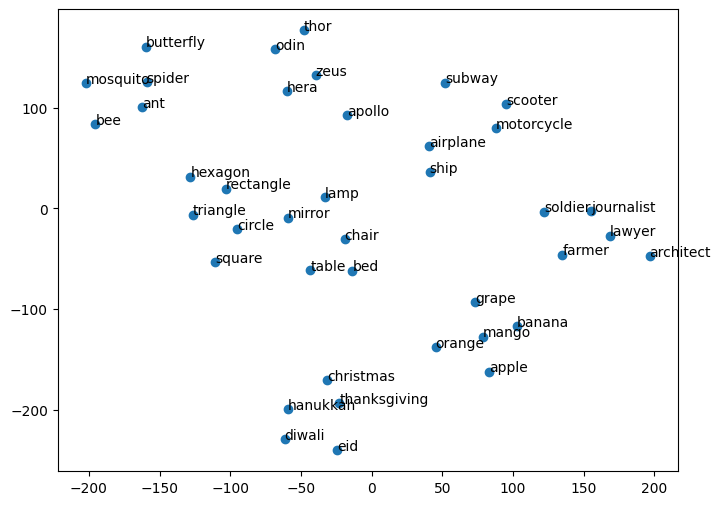

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(tsne_coordinates[:,0], tsne_coordinates[:,1])

for i, word in enumerate(word_list):
    plt.annotate(word, (tsne_coordinates[i,0], tsne_coordinates[i,1]))

plt.show()

In [11]:
tsne = TSNE(
    n_components=2,      # Reduce to 2D
    random_state=42,
    perplexity=10,
    learning_rate=200
)

tsne_coordinates = tsne.fit_transform(vectors_glove)

# Store results
print("Original Shape:", vectors_glove.shape)
print("Reduced Shape:", tsne_coordinates.shape)

# Display first 5 coordinates
print("\nFirst 5 t-SNE Coordinates:")
print(tsne_coordinates[:5])
# Display first 5 coordinates of glove
print("\nFirst 5 t-SNE Coordinates:")
print(vectors_glove[:5])

Original Shape: (40, 100)
Reduced Shape: (40, 2)

First 5 t-SNE Coordinates:
[[-39.629234 132.0537  ]
 [-59.71     116.74179 ]
 [-17.504345  92.75576 ]
 [-68.02977  157.89868 ]
 [-47.945087 176.97955 ]]

First 5 t-SNE Coordinates:
[[ 2.1534e-01  4.6497e-01  3.4684e-01  3.6058e-01 -6.1938e-01  7.1045e-01
  -5.2483e-01 -6.8764e-01  2.4996e-01 -2.4169e-01  2.5155e-01  4.1229e-01
   8.5005e-01  6.0297e-01 -2.0636e-01 -9.2409e-01  7.7317e-02  1.0427e+00
  -7.6307e-01  6.9264e-01 -9.2247e-01 -1.2863e+00 -8.6955e-01  1.2029e+00
   5.4891e-01  4.4451e-01 -1.3946e+00  1.3148e-01 -3.4692e-01  2.7659e-01
   4.8882e-01 -6.5474e-02 -5.8949e-01  9.6504e-01  1.6484e-01 -1.5887e-01
   1.4522e-02  5.1853e-01  3.7734e-01 -5.5546e-01  5.1987e-04  9.1871e-01
  -4.0175e-02 -5.4081e-01 -7.0852e-02  2.7819e-02 -1.4158e-01  3.7013e-01
   3.7487e-01  6.2157e-01 -3.8152e-01  6.5442e-01  1.1006e+00  4.7546e-01
  -4.1251e-01 -5.5896e-01  1.3095e-01  5.0395e-01 -5.8674e-01 -1.1780e-01
   4.1186e-01  4.2969e-01  8.

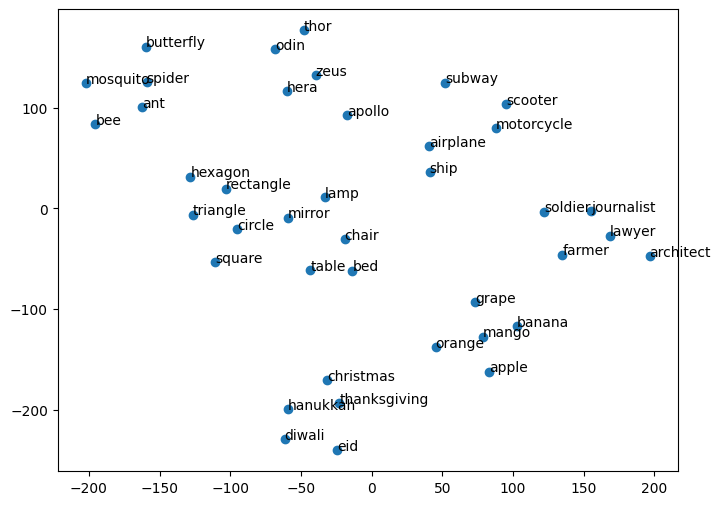

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(tsne_coordinates[:,0], tsne_coordinates[:,1])

for i, word in enumerate(word_list):
    plt.annotate(word, (tsne_coordinates[i,0], tsne_coordinates[i,1]))

plt.show()